# Лабораторная работа: data pipeline и JOIN

Ноутбук использует модули из `src/`. Перед запуском загрузки транзакций запустите FastAPI:
`python -m uvicorn app.main:app --host 127.0.0.1 --port 8000`.

In [1]:
from pathlib import Path
import sqlite3
import matplotlib.pyplot as plt
import pandas as pd

BASE_DIR = Path.cwd()
while BASE_DIR.name != "lab_2" and BASE_DIR.parent != BASE_DIR:
    BASE_DIR = BASE_DIR.parent
DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
PROCESSED_DIR = DATA_DIR / "processed"

from src.database import aggregate_transactions, create_database, run_joins
from src.loaders import load_sources
from src.transform import build_data_mart, join_sources, key_diagnostics, normalize_keys

In [2]:
sources = load_sources(DATA_DIR)
organizations = sources["organizations"]
transactions = sources["transactions"]
cities = sources["cities"]

def inspect_dataset(name, frame, keys):
    print(f"\n{name}: shape={frame.shape}")
    print(frame.dtypes)
    display(frame.head())
    print("NULL:\n", frame.isna().sum())
    print("Уникальные ключи:", {key: frame[key].nunique(dropna=True) for key in keys})
    print("Дубликаты строк:", int(frame.duplicated().sum()))

inspect_dataset("organizations", organizations, ["org_id"])
inspect_dataset("transactions", transactions, ["transaction_id", "org_id"])
inspect_dataset("cities", cities, ["city_id"])



organizations: shape=(10, 4)
org_id       int64
org_name    object
city_id      int64
sector      object
dtype: object


,org_id,org_name,city_id,sector
0,1,Alpha Trade LLC,101,Retail
1,2,Beta Logistics,102,Logistics
2,3,Gamma Foods,103,Food
3,4,Delta Energy,104,Energy
4,5,Epsilon Finance,105,Finance


NULL:
 org_id      0
org_name    0
city_id     0
sector      0
dtype: int64
Уникальные ключи: {'org_id': 10}
Дубликаты строк: 0

transactions: shape=(11, 5)
org_id              int64
date               object
amount            float64
currency           object
transaction_id      int64
dtype: object


,org_id,date,amount,currency,transaction_id
0,1,2026-09-01,12500.50,RUB,1001
1,2,2026-09-02,7800.00,RUB,1002
2,3,2026-09-03,15420.75,RUB,1003
3,4,2026-09-04,2210.00,RUB,1004
4,5,2026-09-05,98000.00,RUB,1005


NULL:
 org_id            0
date              0
amount            0
currency          0
transaction_id    0
dtype: int64
Уникальные ключи: {'transaction_id': 10, 'org_id': 10}
Дубликаты строк: 1

cities: shape=(10, 4)
city_id         int64
city_name      object
region_name    object
population      int64
dtype: object


,city_id,city_name,region_name,population
0,101,Moscow,Moscow Region,12655050
1,102,Saint Petersburg,Leningrad Region,5384342
2,103,Kazan,Tatarstan,1257391
3,104,Yekaterinburg,Sverdlovsk Region,1544376
4,105,Novosibirsk,Novosibirsk Region,1625631


NULL:
 city_id        0
city_name      0
region_name    0
population     0
dtype: int64
Уникальные ключи: {'city_id': 10}
Дубликаты строк: 0


In [3]:
organizations, transactions, cities = normalize_keys(organizations, transactions, cities)
print("Кардинальность organizations.org_id -> transactions.org_id: 1:N")
print("Кардинальность organizations.city_id -> cities.city_id: N:1")
print(key_diagnostics(organizations, "org_id", transactions, "org_id"))
print(key_diagnostics(organizations, "city_id", cities, "city_id"))

Кардинальность organizations.org_id -> transactions.org_id: 1:N
Кардинальность organizations.city_id -> cities.city_id: N:1
{'null_left': 0, 'null_right': 0, 'duplicate_keys_left': Empty DataFrame
Columns: [org_id, org_name, city_id, sector]
Index: [], 'duplicate_keys_right':     org_id        date   amount currency  transaction_id
9      999  2026-09-10  1111.11      RUB            1010
10     999  2026-09-10  1111.11      RUB            1010, 'left_only': [np.int64(10)], 'right_only': [np.int64(999)]}
{'null_left': 0, 'null_right': 0, 'duplicate_keys_left': Empty DataFrame
Columns: [org_id, org_name, city_id, sector]
Index: [], 'duplicate_keys_right': Empty DataFrame
Columns: [city_id, city_name, region_name, population]
Index: [], 'left_only': [], 'right_only': []}


In [4]:
joins = join_sources(organizations, transactions, cities)
for name, frame in joins.items():
    print(f"{name}: {len(frame)} строк")
    marker = "city_merge" if "city_merge" in frame else "_merge"
    print(frame[marker].value_counts(dropna=False).to_dict())
    display(frame.head())

inner_org_tx: 9 строк
{'both': 9, 'left_only': 0, 'right_only': 0}


,org_id,org_name,city_id,sector,date,amount,currency,transaction_id,_merge
0,1,Alpha Trade LLC,101,Retail,2026-09-01,12500.50,RUB,1001,both
1,2,Beta Logistics,102,Logistics,2026-09-02,7800.00,RUB,1002,both
2,3,Gamma Foods,103,Food,2026-09-03,15420.75,RUB,1003,both
3,4,Delta Energy,104,Energy,2026-09-04,2210.00,RUB,1004,both
4,5,Epsilon Finance,105,Finance,2026-09-05,98000.00,RUB,1005,both


left_org_tx: 10 строк
{'both': 9, 'left_only': 1, 'right_only': 0}


,org_id,org_name,city_id,sector,date,amount,currency,transaction_id,_merge
0,1,Alpha Trade LLC,101,Retail,2026-09-01,12500.50,RUB,1001.0,both
1,2,Beta Logistics,102,Logistics,2026-09-02,7800.00,RUB,1002.0,both
2,3,Gamma Foods,103,Food,2026-09-03,15420.75,RUB,1003.0,both
3,4,Delta Energy,104,Energy,2026-09-04,2210.00,RUB,1004.0,both
4,5,Epsilon Finance,105,Finance,2026-09-05,98000.00,RUB,1005.0,both


with_cities: 10 строк
{'both': 10, 'left_only': 0, 'right_only': 0}


,org_id,org_name,city_id,sector,date,amount,currency,transaction_id,_merge,city_name,region_name,population,city_merge
0,1,Alpha Trade LLC,101,Retail,2026-09-01,12500.50,RUB,1001.0,both,Moscow,Moscow Region,12655050,both
1,2,Beta Logistics,102,Logistics,2026-09-02,7800.00,RUB,1002.0,both,Saint Petersburg,Leningrad Region,5384342,both
2,3,Gamma Foods,103,Food,2026-09-03,15420.75,RUB,1003.0,both,Kazan,Tatarstan,1257391,both
3,4,Delta Energy,104,Energy,2026-09-04,2210.00,RUB,1004.0,both,Yekaterinburg,Sverdlovsk Region,1544376,both
4,5,Epsilon Finance,105,Finance,2026-09-05,98000.00,RUB,1005.0,both,Novosibirsk,Novosibirsk Region,1625631,both


In [5]:
with sqlite3.connect(":memory:") as connection:
    create_database(connection, organizations, transactions, cities)
    sql_joins = run_joins(connection)
    sql_aggregates = aggregate_transactions(connection)

display(sql_joins["inner_org_tx"].head())
display(sql_joins["left_org_tx"].head())
display(sql_aggregates)
print("SQL INNER JOIN строк:", len(sql_joins["inner_org_tx"]))
print("SQL LEFT JOIN строк:", len(sql_joins["left_org_tx"]))

,org_id,org_name,transaction_id,date,amount,currency
0,1,Alpha Trade LLC,1001,2026-09-01,12500.50,RUB
1,2,Beta Logistics,1002,2026-09-02,7800.00,RUB
2,3,Gamma Foods,1003,2026-09-03,15420.75,RUB
3,4,Delta Energy,1004,2026-09-04,2210.00,RUB
4,5,Epsilon Finance,1005,2026-09-05,98000.00,RUB


,org_id,org_name,city_id,transaction_id,date,amount,currency
0,1,Alpha Trade LLC,101,1001.0,2026-09-01,12500.50,RUB
1,2,Beta Logistics,102,1002.0,2026-09-02,7800.00,RUB
2,3,Gamma Foods,103,1003.0,2026-09-03,15420.75,RUB
3,4,Delta Energy,104,1004.0,2026-09-04,2210.00,RUB
4,5,Epsilon Finance,105,1005.0,2026-09-05,98000.00,RUB


,org_id,org_name,transaction_count,amount_sum,amount_avg
0,1,Alpha Trade LLC,1,12500.50,12500.50
1,2,Beta Logistics,1,7800.00,7800.00
2,3,Gamma Foods,1,15420.75,15420.75
3,4,Delta Energy,1,2210.00,2210.00
4,5,Epsilon Finance,1,98000.00,98000.00
5,6,Zeta Health,1,6400.25,6400.25
6,7,Eta Education,1,8700.00,8700.00
7,8,Theta Tech,1,31250.00,31250.00
8,9,Iota Construction,1,4590.90,4590.90
9,10,Kappa Media,0,0.00,NaN


SQL INNER JOIN строк: 9
SQL LEFT JOIN строк: 10


In [6]:
data_mart = build_data_mart(organizations, transactions, cities)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
data_mart.to_csv(PROCESSED_DIR / "data_mart.csv", index=False, encoding="utf-8-sig")
data_mart.to_parquet(PROCESSED_DIR / "data_mart.parquet", index=False)
display(data_mart)

,org_id,org_name,sector,city_name,region_name,transactions_count,total_amount,avg_amount,last_transaction_date
0,1,Alpha Trade LLC,Retail,Moscow,Moscow Region,1,12500.50,12500.50,2026-09-01
1,2,Beta Logistics,Logistics,Saint Petersburg,Leningrad Region,1,7800.00,7800.00,2026-09-02
2,3,Gamma Foods,Food,Kazan,Tatarstan,1,15420.75,15420.75,2026-09-03
3,4,Delta Energy,Energy,Yekaterinburg,Sverdlovsk Region,1,2210.00,2210.00,2026-09-04
4,5,Epsilon Finance,Finance,Novosibirsk,Novosibirsk Region,1,98000.00,98000.00,2026-09-05
5,6,Zeta Health,Healthcare,Nizhny Novgorod,Nizhny Novgorod Region,1,6400.25,6400.25,2026-09-06
6,7,Eta Education,Education,Samara,Samara Region,1,8700.00,8700.00,2026-09-07
7,8,Theta Tech,IT,Perm,Perm Krai,1,31250.00,31250.00,2026-09-08
8,9,Iota Construction,Construction,Krasnoyarsk,Krasnoyarsk Krai,1,4590.90,4590.90,2026-09-09
9,10,Kappa Media,Media,Vladivostok,Primorsky Krai,0,0.00,NaN,NaN


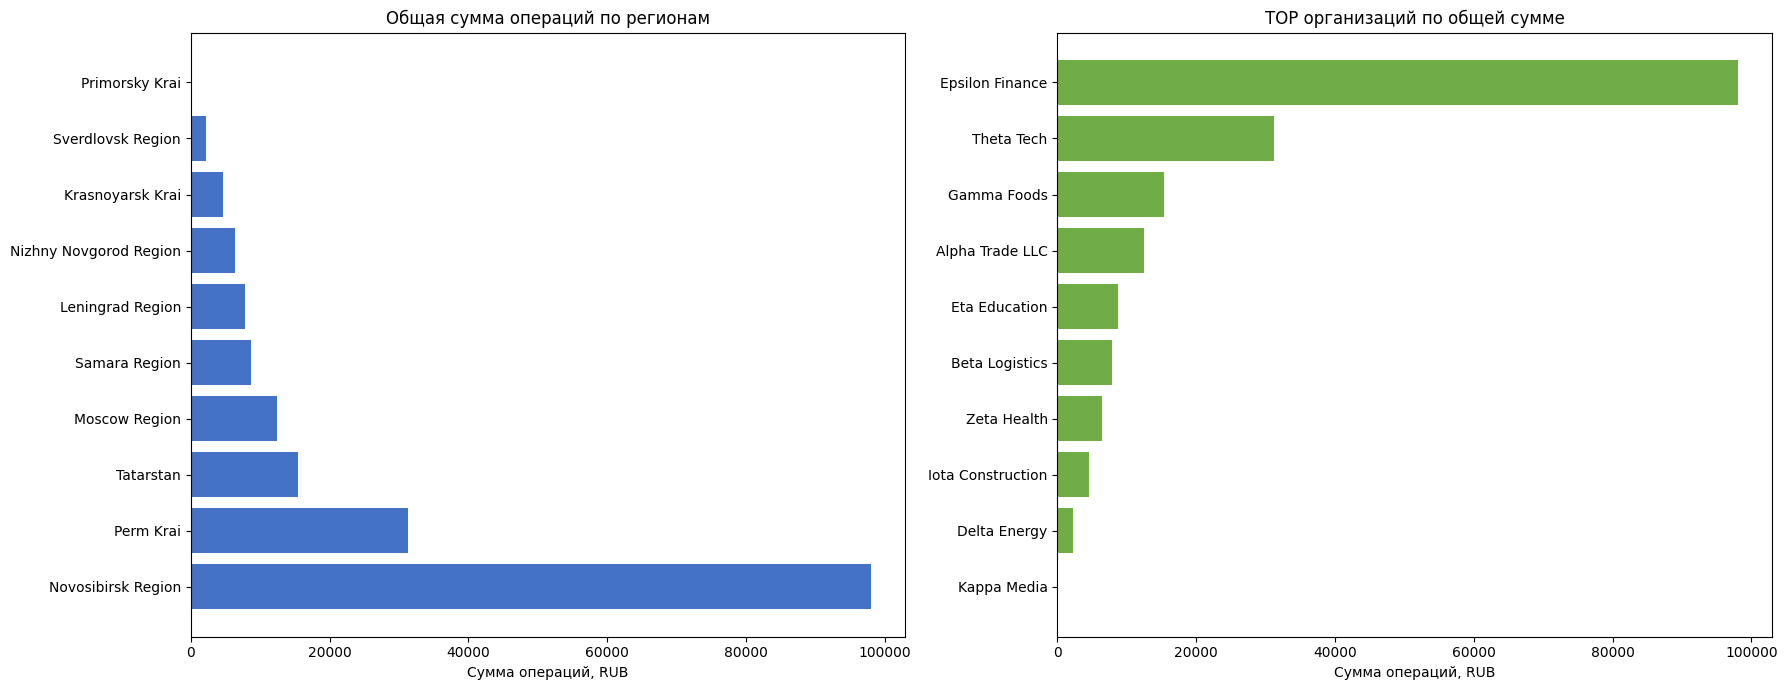

In [7]:
region_totals = data_mart.groupby("region_name", dropna=False, as_index=False)["total_amount"].sum().sort_values("total_amount", ascending=False)
top_organizations = data_mart.nlargest(10, "total_amount").sort_values("total_amount")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].barh(region_totals["region_name"], region_totals["total_amount"], color="#4472C4")
axes[0].set_title("Общая сумма операций по регионам")
axes[0].set_xlabel("Сумма операций, RUB")
axes[1].barh(top_organizations["org_name"], top_organizations["total_amount"], color="#70AD47")
axes[1].set_title("TOP организаций по общей сумме")
axes[1].set_xlabel("Сумма операций, RUB")
plt.tight_layout()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(RESULTS_DIR / "dashboard.png", dpi=150)
plt.show()